In [1]:
# --- path bootstrap: make `src` importable and repo-relative paths resolve ---
# This notebook lives in experiments/notebooks/; run this cell first.
import os, sys
from pathlib import Path

PROJECT_ROOT = Path("/root/Hessian-Approximation-for-Toy-Models")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)  # restore repo root as cwd for relative data/figure paths


In [2]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "7"  # pick the GPU you want

# only now import jax:
import jax

print(jax.devices())  # → [CudaDevice(id=0)]  (the one you picked, renumbered to 0)

model_path = "/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/digits/mlp_08580ee2573a/epoch_10/checkpoint.msgpack"

# Load checkpoint + the train/test split the model was trained on.
from pathlib import Path

import jax

from src.utils.loss import get_loss
from src.utils.train import load_model_checkpoint, load_train_test_for_model

# `model_path` was set in cell-2; derive base dir + epoch.
ckpt = Path(model_path)
EPOCH = (
    int(ckpt.parent.name.split("_")[1])
    if ckpt.parent.name.startswith("epoch_")
    else None
)
EPOCH = 10
MODEL_DIR = str(ckpt.parent.parent if EPOCH is not None else ckpt.parent)

USE_SPLIT = "train"  # "train" or "test"

params, model, model_config, metadata = load_model_checkpoint(MODEL_DIR, epoch=EPOCH)
train_ds, test_ds = load_train_test_for_model(MODEL_DIR)
ds = train_ds if USE_SPLIT == "train" else test_ds
loss_fn = get_loss(model_config.loss)

n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))
print(f"model: {model_config.architecture.value}  hidden={model_config.hidden_dim}")
print(
    f"epoch: {EPOCH}   num_params: {n_params}   split: {USE_SPLIT} ({len(ds.inputs)})"
)


# Collect per-sample gradients via the same path analyze_hessians uses
# (sample_vectors → sample_gradients under the hood, vmapped + jit).
import numpy as np

from src.config import VectorAnalysisConfig, VectorSamplingMethod
from src.hessians.utils.pseudo_targets import sample_vectors

N_GRADS = 1000
ANALYSIS_SEED = 42

vector_cfg = VectorAnalysisConfig(
    num_samples=N_GRADS,
    sampling_method=VectorSamplingMethod.GRADIENTS,
)

G = sample_vectors(
    vector_cfg,
    model=model,
    params=params,
    inputs=ds.inputs,
    targets=ds.targets,
    loss_fn=loss_fn,
    analysis_seed=ANALYSIS_SEED,
)
G = np.asarray(G)
print(f"gradient matrix: {G.shape}   ({G.nbytes / 1e6:.1f} MB)")


[CpuDevice(id=0)]
model: mlp  hidden=[16, 16, 16, 16, 16, 16, 16, 16]
epoch: 10   num_params: 2976   split: train (3823)
gradient matrix: (1000, 2976)   (11.9 MB)


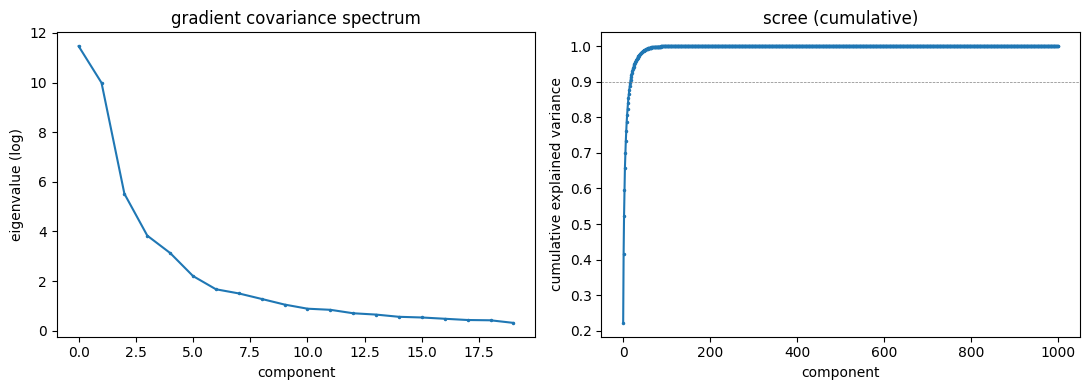

top 5 eigvals:    [11.465196   9.988555   5.51698    3.829318   3.1289937]
#comps for 90% variance: 18
effective rank (1/Σ pᵢ²): 8.8


In [3]:
# PCA via SVD of the centered gradient matrix.
# G is (N, D), so SVD is O(N²·D); for thin matrices this is cheap.
# σᵢ are singular values; gradient-covariance eigenvalues are σᵢ² / N.
import matplotlib.pyplot as plt

G_centered = G - G.mean(axis=0, keepdims=True)
G_centered = G
sv = np.linalg.svd(G_centered, compute_uv=False)
eigvals = sv**2 / G.shape[0]
explained = eigvals / eigvals.sum()
cumulative = np.cumsum(explained)
eigvals_plot = eigvals[:20]
log_scale = False
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
if log_scale == True:
    axes[0].semilogy(eigvals_plot, ".-", ms=3)
else:
    axes[0].plot(eigvals_plot, ".-", ms=3)

axes[0].set(
    xlabel="component", ylabel="eigenvalue (log)", title="gradient covariance spectrum"
)

axes[1].plot(cumulative, ".-", ms=3)
axes[1].axhline(0.9, ls="--", color="grey", lw=0.5)
axes[1].set(
    xlabel="component",
    ylabel="cumulative explained variance",
    title="scree (cumulative)",
)

plt.tight_layout()
plt.show()

print(f"top 5 eigvals:    {eigvals[:5]}")
print(f"#comps for 90% variance: {int(np.searchsorted(cumulative, 0.9)) + 1}")
print(f"effective rank (1/Σ pᵢ²): {1.0 / np.sum(explained**2):.1f}")


In [4]:
# Residual subspace alignment.
#
# Instead of asking how Hessian eigenvector *directions* line up with the
# gradient subspace, we look at the residual error of each approximator
#
#     D = H - H_approx
#
# and ask what fraction of *its* Frobenius energy lives in the gradient
# subspace V_grad (orthonormal columns = top-n gradient-PCA directions):
#
#     align(D, V_grad) = ||D V_grad||_F^2 / ||D||_F^2   in [0, 1].
#
# Since V_grad is orthonormal, ||D V||_F^2 = tr(Vᵀ D² V) = ||D P||_F^2 with
# P = V Vᵀ — i.e. the share of D's action captured by the gradient subspace.
# Random-subspace baseline: E[align] = n / D_dim.
from src.hessians.layer_matrix import LayerMatrix

FACTORS_DIR = Path(
    "/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/"
    "digits/mlp_08580ee2573a/epoch_10/collector_mcmc_r1_s42/factors"
)
HESSIAN_DIR = FACTORS_DIR / "exact_hessian_layer_matrix"
GNH_DIR = FACTORS_DIR / "gnh_layer_matrix"

# HESSIAN_DIR = GNH_DIR


def load_sym(d: Path) -> np.ndarray:
    """Densify a layer matrix and symmetrize it."""
    M = np.asarray(LayerMatrix.load(d).to_dense())
    return (M + M.T) / 2


H = load_sym(HESSIAN_DIR)
D_dim = H.shape[0]

# Gradient subspace: top-n PCA directions (orthonormal columns). n = effective rank.
n = int(round(1.0 / np.sum(explained**2)))
_, _, Vt = np.linalg.svd(G_centered, full_matrices=False)
V_grad = Vt[:n].T  # (D_dim, n), orthonormal columns
assert V_grad.shape[0] == D_dim, (V_grad.shape, D_dim)


def subspace_alignment(Dmat: np.ndarray, V: np.ndarray) -> float:
    """||D V||_F^2 / ||D||_F^2 for V with orthonormal columns."""
    num = np.linalg.norm(Dmat @ V, "fro") ** 2
    den = np.linalg.norm(Dmat, "fro") ** 2
    return float(num / den)


print(f"D_dim = {D_dim}   n = {n}   random baseline n/D = {n / D_dim:.4f}")


D_dim = 2976   n = 9   random baseline n/D = 0.0030


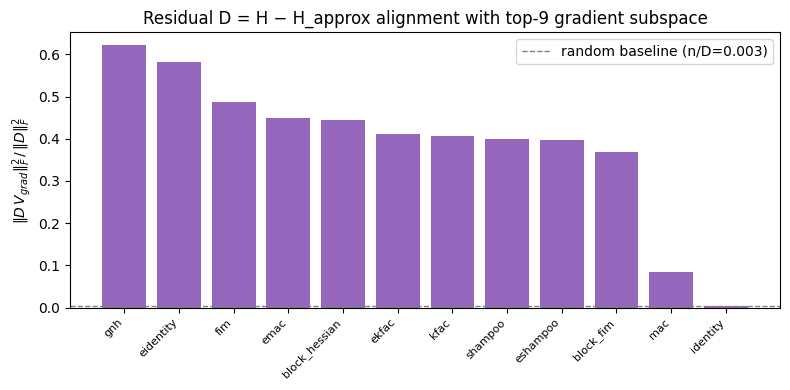

gnh                             align = 0.6212   (×baseline = 205.4)
eidentity                       align = 0.5825   (×baseline = 192.6)
fim                             align = 0.4877   (×baseline = 161.3)
emac                            align = 0.4502   (×baseline = 148.9)
block_hessian                   align = 0.4449   (×baseline = 147.1)
ekfac                           align = 0.4110   (×baseline = 135.9)
kfac                            align = 0.4066   (×baseline = 134.5)
shampoo                         align = 0.3984   (×baseline = 131.7)
eshampoo                        align = 0.3969   (×baseline = 131.2)
block_fim                       align = 0.3677   (×baseline = 121.6)
mac                             align = 0.0842   (×baseline = 27.9)
identity                        align = 0.0036   (×baseline = 1.2)


In [5]:
# Per-approximator residual alignment at the effective-rank subspace.
# Bars > baseline => the approximator's error D = H - H_approx is concentrated
# in the gradient subspace (i.e. it errs exactly where the gradients live).
approx_dirs = sorted(
    d
    for d in FACTORS_DIR.iterdir()
    if d.is_dir() and d.name != "exact_hessian_layer_matrix"
)

names, aligns = [], []
for ad in approx_dirs:
    Dmat = H - load_sym(ad)
    names.append(ad.name.removesuffix("_layer_matrix"))
    aligns.append(subspace_alignment(Dmat, V_grad))

order = np.argsort(aligns)[::-1]
names = [names[i] for i in order]
aligns = [aligns[i] for i in order]
baseline = n / D_dim

fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(names)), 4))
ax.bar(range(len(names)), aligns, color="tab:purple")
ax.axhline(
    baseline, ls="--", color="grey", lw=1, label=f"random baseline (n/D={baseline:.3f})"
)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(r"$\|D\,V_{grad}\|_F^2 \, / \, \|D\|_F^2$")
ax.set_title(f"Residual D = H − H_approx alignment with top-{n} gradient subspace")
ax.legend()
plt.tight_layout()
plt.show()

for nm, a in zip(names, aligns):
    print(f"{nm:30s}  align = {a:.4f}   (×baseline = {a / baseline:.1f})")


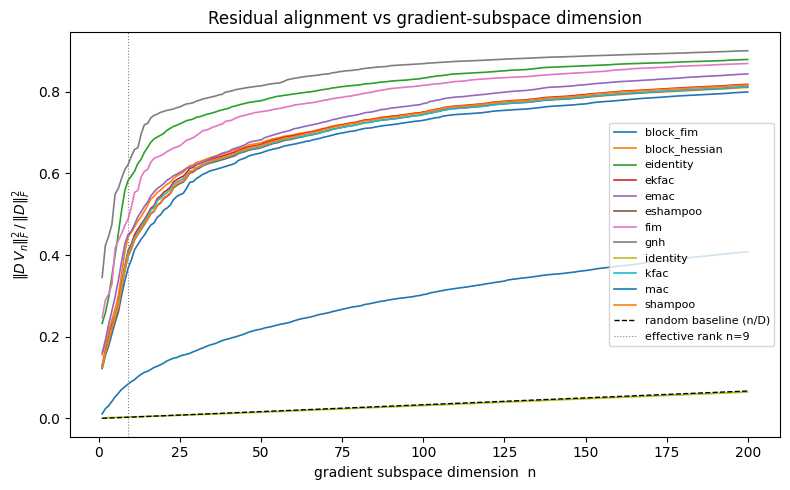

In [6]:
# Alignment as a function of the gradient-subspace dimension n.
#
# V_n = top-n PCA directions (orthonormal), so by Parseval
#   ||D V_n||_F^2 = Σ_{j<=n} ||D v_j||^2,
# and the curve is just the cumulative per-direction energy divided by ||D||_F^2.
# The dashed diagonal n/D is the random-subspace expectation; curves above it
# mean the error is preferentially aligned with the leading gradient directions.
_, _, Vt_full = np.linalg.svd(G_centered, full_matrices=False)
R = Vt_full.shape[0]  # available PCA directions
N_MAX = min(R, 200)

fig, ax = plt.subplots(figsize=(8, 5))
for ad in approx_dirs:
    Dmat = H - load_sym(ad)
    den = np.linalg.norm(Dmat, "fro") ** 2
    DV = Dmat @ Vt_full.T  # (D_dim, R)
    col_energy = (DV**2).sum(axis=0)  # ||D v_j||^2 per PCA direction
    cum = np.cumsum(col_energy) / den  # align(n) for n = 1..R
    ax.plot(
        np.arange(1, N_MAX + 1),
        cum[:N_MAX],
        "-",
        lw=1.2,
        label=ad.name.removesuffix("_layer_matrix"),
    )

ns = np.arange(1, N_MAX + 1)
ax.plot(ns, ns / D_dim, "k--", lw=1, label="random baseline (n/D)")
ax.axvline(n, ls=":", color="grey", lw=0.8, label=f"effective rank n={n}")
ax.set_xlabel("gradient subspace dimension  n")
ax.set_ylabel(r"$\|D\,V_n\|_F^2 \, / \, \|D\|_F^2$")
ax.set_title("Residual alignment vs gradient-subspace dimension")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [7]:
# C-weighted optimal eigenvalue correction ("ckfac"): task-optimal Λ in the
# K-FAC eigenbasis.
#
# Fitting within a linear class is orthogonal projection in the risk inner
# product ⟨X, Y⟩_C = tr(X C Yᵀ).  For the class
#
#     { Σ_l Q_l Λ_l Q_lᵀ : Λ_l diagonal },   Q_l = Q_A ⊗ Q_G  (K-FAC basis),
#
# the basis elements q_i q_iᵀ have a *diagonal* C-Gram (the q_i are orthonormal
# with disjoint block supports), so the projection is coordinate-wise:
#
#     λ_i = q_iᵀ sym(C H) q_i / q_iᵀ C q_i ,
#
# and the Frobenius-optimal (exact-EKFAC) λ_i = q_iᵀ H q_i is its C = I special
# case.  sym(C H) is sliced *after* the full product: C's cross-layer blocks
# couple the in-block diagonal to the off-block part of H, so the fit can
# overshoot in gradient-heavy directions to mimic curvature the block-diagonal
# family cannot represent — large ||D||_F, small ||D C^{1/2}||_F by design.
#
# C = GᵀG/N is rank-deficient when N_GRADS < D_dim; directions whose probe
# energy sits at the float32 noise floor are risk-indifferent, so they keep
# the Frobenius-optimal value as tie-break.
ekfac_lm = LayerMatrix.load(FACTORS_DIR / "ekfac_layer_matrix")  # same Q as kfac
groups = list(ekfac_lm.param_groups)
sizes = [int(np.prod(ekfac_lm.blocks[(g, g)].vector_shape)) for g in groups]
offsets = np.concatenate([[0], np.cumsum(sizes)]).astype(int)
assert offsets[-1] == D_dim

G64 = G_centered.astype(np.float64)
C = G64.T @ G64 / G64.shape[0]
H64 = H.astype(np.float64)
M_CH = (C @ H64 + H64 @ C) / 2  # sym(C H)

A_ckfac = np.zeros_like(H64)
n_dead = 0
for li, layer in enumerate(groups):
    blk = ekfac_lm.blocks[(layer, layer)]
    Q = np.kron(np.asarray(blk.Q_A, np.float64), np.asarray(blk.Q_G, np.float64))
    sl = slice(offsets[li], offsets[li + 1])
    num = ((M_CH[sl, sl] @ Q) * Q).sum(axis=0)  # q_iᵀ sym(CH) q_i
    den = ((C[sl, sl] @ Q) * Q).sum(axis=0)  # q_iᵀ C q_i ≥ 0
    lam_frob = ((H64[sl, sl] @ Q) * Q).sum(axis=0)  # C = I solution
    dead = den <= np.finfo(np.float32).eps * den.max()
    lam = np.where(dead, lam_frob, num / np.where(dead, 1.0, den))
    n_dead += int(dead.sum())
    A_ckfac[sl, sl] = (Q * lam) @ Q.T

# hand the scatter cell the extra approximation (name follows the e-prefix scheme)
extra_approx = {"ckfac": A_ckfac.astype(H.dtype)}

# context: blockdiag(H) is the Frobenius-optimal block-diagonal approximation;
# ckfac trades ||D||_F away to undercut its *risk*.
S_off = H64.copy()
for li in range(len(groups)):
    sl = slice(offsets[li], offsets[li + 1])
    S_off[sl, sl] = 0.0
D_cw = H64 - A_ckfac
for tag, Dm in [("ckfac", D_cw), ("blockdiag(H) floor", S_off)]:
    risk = float(np.sqrt(np.sum((Dm @ C) * Dm)))  # ||D C^1/2||_F for symmetric D
    print(
        f"{tag:20s}  ||D||_F = {np.linalg.norm(Dm):.4g}    ||D C^1/2||_F = {risk:.4g}"
    )
print(f"risk-indifferent directions (kept Frobenius λ): {n_dead}/{D_dim}")


ckfac                 ||D||_F = 20.47    ||D C^1/2||_F = 5.958
blockdiag(H) floor    ||D||_F = 3.872    ||D C^1/2||_F = 6.48
risk-indifferent directions (kept Frobenius λ): 153/2976


saved -> figures/residual_vs_covweighted.pdf


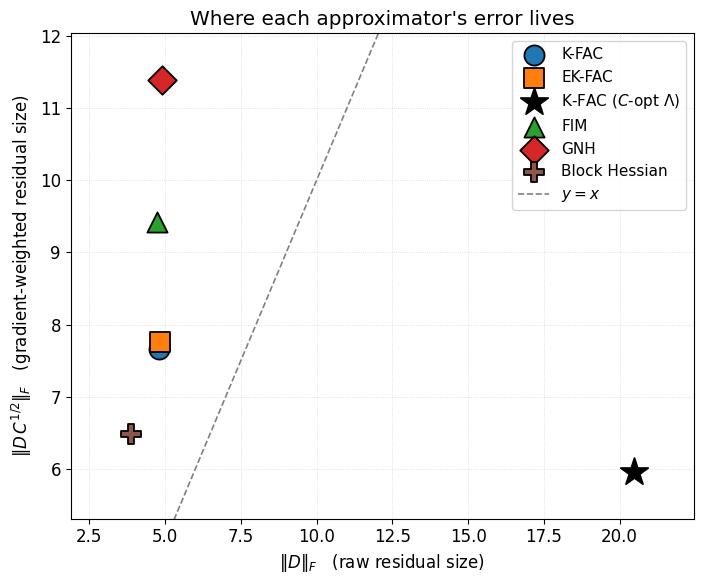

kfac                            ||D||_F = 4.814    ||D C^1/2||_F = 7.666
ekfac                           ||D||_F = 4.816    ||D C^1/2||_F = 7.751
ckfac                           ||D||_F = 20.47    ||D C^1/2||_F = 5.958
fim                             ||D||_F = 4.734    ||D C^1/2||_F = 9.42
gnh                             ||D||_F = 4.886    ||D C^1/2||_F = 11.39
block_hessian                   ||D||_F = 3.872    ||D C^1/2||_F = 6.48


In [8]:
# Scatter: raw residual size  vs  covariance-weighted residual size.
#
#   x = ||D||_F                 (overall error of H_approx)
#   y = ||D C^{1/2}||_F         (error weighted by the gradient covariance C)
#
# C = (1/N) G_cᵀ G_c is the gradient covariance. With SVD G_c = W Σ Vᵀ we have
# C = V (Σ²/N) Vᵀ, so C^{1/2} = V diag(σ/√N) Vᵀ and, since right-multiplying by
# the orthonormal Vᵀ preserves the Frobenius norm,
#   ||D C^{1/2}||_F² = Σ_j ||D v_j||² · (σ_j²/N) = Σ_j ||D v_j||² · λ_j(C).
# Methods low on y but high on x err mostly *outside* the gradient subspace.
import matplotlib.pyplot as plt

# ------------------------------------------------------------------ #
#  EDIT ME: which approximators to plot, and in what order.          #
#  Names are the factor-dir names without the "_layer_matrix" suffix #
#  (e.g. "kfac", "ekfac", "gnh", "block_fim", ...).                  #
#  Set PLOT = None to use every available approximator.              #
# ------------------------------------------------------------------ #
PLOT = [
    # "identity",
    "kfac",
    "ekfac",
    "ckfac",
    # "shampoo",
    # "eshampoo",
    "fim",
    "gnh",
    "block_hessian",
]
# nicer legend labels (falls back to the raw name if absent)
LABELS = {
    "identity": "Identity",
    "kfac": "K-FAC",
    "ekfac": "EK-FAC",
    "ckfac": r"K-FAC ($C$-opt $\Lambda$)",
    "shampoo": "Shampoo",
    "eshampoo": "E-Shampoo",
    "gnh": "GNH",
    "block_hessian": "Block Hessian",
    "fim": "FIM",
    "block_fim": "Block FIM",
    "mac": "MAC",
    "emac": "E-MAC",
    "eidentity": "E-Identity",
}
# Per-method colours, matched to plots/hessian_plots.py so figures agree across
# the repo. "ckfac" is a notebook-only extra (not in that palette) → black, to
# flag it as the special C-optimal fit.
COLORS = {
    "kfac": "#1f77b4", "ekfac": "#ff7f0e", "gnh": "#d62728", "fim": "#2ca02c",
    "block_fim": "#9467bd", "block_hessian": "#8c564b", "shampoo": "#e377c2",
    "eshampoo": "#7f7f7f", "identity": "#17becf", "eidentity": "#9edae5",
    "exact": "#bcbd22", "mac": "#393b79", "emac": "#637939", "ckfac": "#000000",
}
# Fixed per-method marker so a method reads the same shape across every figure.
# ckfac (the special C-optimal fit) gets the star.
MARKERS = {
    "kfac": "o", "ekfac": "s", "ckfac": "*", "fim": "^", "gnh": "D",
    "block_hessian": "P", "block_fim": "X", "shampoo": "v", "eshampoo": "<",
    "identity": "p", "eidentity": ">", "exact": "h", "mac": "d", "emac": "8",
}
SAVE_PDF = True
PDF_PATH = Path("figures") / "residual_vs_covweighted.pdf"

# ---- per-approximator residual sizes ----
_, _, Vt_full = np.linalg.svd(G_centered, full_matrices=False)
sqrt_cov_eig = sv[: Vt_full.shape[0]] / np.sqrt(G.shape[0])  # σ_j / √N = √λ_j(C)

records = {}  # name -> (||D||_F, ||D C^1/2||_F)
for ad in approx_dirs:
    Dmat = H - load_sym(ad)
    DV = Dmat @ Vt_full.T  # (D_dim, R)
    col_energy = (DV**2).sum(axis=0)  # ||D v_j||²
    name = ad.name.removesuffix("_layer_matrix")
    records[name] = (
        float(np.linalg.norm(Dmat, "fro")),
        float(np.sqrt((col_energy * sqrt_cov_eig**2).sum())),
    )

# in-memory approximations from other cells (e.g. "ckfac"), same metrics
for name, A in (extra_approx if "extra_approx" in globals() else {}).items():
    Dmat = H - A
    DV = Dmat @ Vt_full.T
    col_energy = (DV**2).sum(axis=0)
    records[name] = (
        float(np.linalg.norm(Dmat, "fro")),
        float(np.sqrt((col_energy * sqrt_cov_eig**2).sum())),
    )

selected = list(records) if PLOT is None else PLOT
missing = [n for n in selected if n not in records]
assert not missing, f"unknown approximator(s): {missing}\navailable: {sorted(records)}"

# ---- salient scatter: big per-method symbols, repo colour scheme + legend ----
plt.rcParams.update({"font.size": 12})
fig, ax = plt.subplots(figsize=(7.2, 6.0))

xs, ys = [], []
for name in selected:
    x, y = records[name]
    xs.append(x)
    ys.append(y)
    marker = MARKERS.get(name, "o")
    # the star reads smaller than the closed shapes at equal `s`; bump it.
    s = 430 if marker == "*" else 210
    ax.scatter(
        x, y,
        s=s,
        marker=marker,
        color=COLORS.get(name, "#444444"),
        edgecolor="black",
        linewidth=1.3,
        zorder=3,
        label=LABELS.get(name, name),
    )

# y = x reference line: on it the weighted error tracks the raw error; points
# *below* it hide their error outside the gradient subspace (the whole point).
hi = max(xs + ys) * 1.2
lo = min(xs + ys) * 0.8
ax.plot([lo, hi], [lo, hi], color="0.5", ls="--", lw=1.2, zorder=1, label=r"$y = x$")

# pad limits so the big markers don't clip at the frame
pad_x = 0.12 * (max(xs) - min(xs) or 1)
pad_y = 0.12 * (max(ys) - min(ys) or 1)
ax.set_xlim(min(xs) - pad_x, max(xs) + pad_x)
ax.set_ylim(min(ys) - pad_y, max(ys) + pad_y)

ax.set_xlabel(r"$\|D\|_F$   (raw residual size)")
ax.set_ylabel(r"$\|D\,C^{1/2}\|_F$   (gradient-weighted residual size)")
ax.set_title("Small MLP3 - epoch 10")
ax.grid(True, ls=":", lw=0.6, alpha=0.5)
ax.legend(loc="best", frameon=True, fontsize=11)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig(PDF_PATH, bbox_inches="tight")
    print(f"saved -> {PDF_PATH}")
plt.show()

for nm in selected:
    x, y = records[nm]
    print(f"{nm:30s}  ||D||_F = {x:.4g}    ||D C^1/2||_F = {y:.4g}")


saved -> figures/grad_matrix_and_covariance.pdf


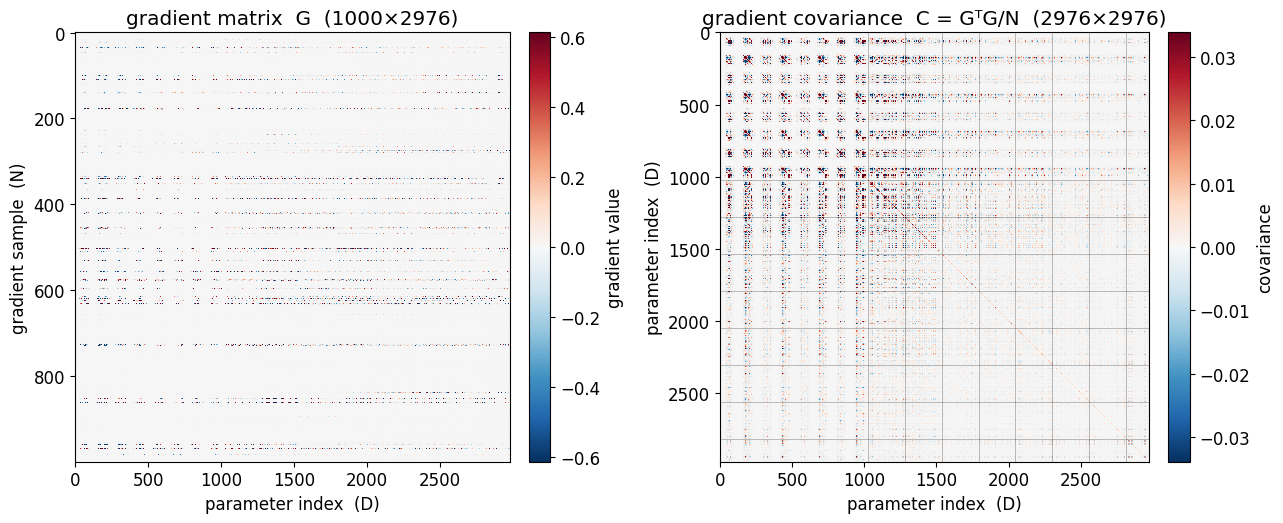

G: shape=(1000, 2976)  |max|=15.7
C: shape=(2976, 2976)  diag mean=0.0173  off-diag energy fraction=0.988


: 

In [9]:
# Heatmaps of the gradient matrix G64 and the gradient covariance C = G64ᵀG64/N.
#
#   left  : G64  (N_grads × D)   raw per-sample gradients, samples down the rows
#   right : C    (D × D)         their covariance; dashed lines = layer blocks
#
# Both use a diverging colormap centred at 0 with symmetric, percentile-robust
# limits (a few outliers don't wash the map out). C's off-diagonal blocks are
# exactly the cross-layer coupling the block-diagonal families (K-FAC, …) throw
# away — and the coupling ckfac exploits in cell-6.
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# G64, C, offsets come from the ckfac cell; recompute G64/C if that wasn't run.
if "G64" not in globals():
    G64 = G_centered.astype(np.float64)
if "C" not in globals():
    C = G64.T @ G64 / G64.shape[0]


def _sym_limit(M, pct=99.5):
    """Symmetric colour limit from a robust percentile of |M| (>0)."""
    return float(np.percentile(np.abs(M), pct)) or float(np.abs(M).max()) or 1.0


fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

# ---- left: gradient matrix ----
gl = _sym_limit(G64)
im0 = axes[0].imshow(
    G64, aspect="auto", cmap="RdBu_r", vmin=-gl, vmax=gl, interpolation="nearest"
)
axes[0].set(
    xlabel="parameter index  (D)",
    ylabel="gradient sample  (N)",
    title=f"gradient matrix  G  ({G64.shape[0]}×{G64.shape[1]})",
)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04).set_label("gradient value")

# ---- right: covariance, with layer-block boundaries ----
cl = _sym_limit(C)
im1 = axes[1].imshow(
    C, cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0.0, vmin=-cl, vmax=cl),
    interpolation="nearest",
)
if "offsets" in globals():
    for b in offsets[1:-1]:
        axes[1].axhline(b - 0.5, color="k", lw=0.5, alpha=0.35)
        axes[1].axvline(b - 0.5, color="k", lw=0.5, alpha=0.35)
axes[1].set(
    xlabel="parameter index  (D)",
    ylabel="parameter index  (D)",
    title=f"gradient covariance  C = GᵀG/N  ({C.shape[0]}×{C.shape[1]})",
)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04).set_label("covariance")

plt.tight_layout()
SAVE_PDF = True
if SAVE_PDF:
    out = Path("figures") / "grad_matrix_and_covariance.pdf"
    plt.savefig(out, bbox_inches="tight")
    print(f"saved -> {out}")
plt.show()

print(f"G: shape={G64.shape}  |max|={np.abs(G64).max():.3g}")
print(
    f"C: shape={C.shape}  diag mean={np.mean(np.diag(C)):.3g}  "
    f"off-diag energy fraction={1 - (np.sum(np.diag(C) ** 2) / np.sum(C ** 2)):.3f}"
)
